<a href="https://colab.research.google.com/github/Ananya-Bhardwaz/TML26_A4_65/blob/main/TML_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())

GPU available: True


In [ ]:
!pip install -q pillow numpy

import os, zipfile
from pathlib import Path
import numpy as np
from PIL import Image, ImageFilter

In [ ]:
!wget -q https://dl.fbaipublicfiles.com/wmforger/convnext_pref_model.pth
print("done")

done


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-6, data_format="channels_first"):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps
        self.data_format = data_format
        self.normalized_shape = (normalized_shape,)

    def forward(self, x):
        if self.data_format == "channels_last":
            return F.layer_norm(x, self.normalized_shape, self.weight, self.bias, self.eps)
        u = x.mean(1, keepdim=True)
        s = (x - u).pow(2).mean(1, keepdim=True)
        x = (x - u) / torch.sqrt(s + self.eps)
        return self.weight[:, None, None] * x + self.bias[:, None, None]

class GRN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1, 1, 1, dim))
        self.beta = nn.Parameter(torch.zeros(1, 1, 1, dim))

    def forward(self, x):
        Gx = torch.norm(x, p=2, dim=(1, 2), keepdim=True)
        Nx = Gx / (Gx.mean(dim=-1, keepdim=True) + 1e-6)
        return self.gamma * (x * Nx) + self.beta + x

class ConvNeXtBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        self.norm = LayerNorm(dim, eps=1e-6, data_format="channels_last")
        self.pwconv1 = nn.Linear(dim, 4 * dim)
        self.act = nn.GELU()
        self.grn = GRN(4 * dim)
        self.pwconv2 = nn.Linear(4 * dim, dim)

    def forward(self, x):
        inp = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1).contiguous()
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.grn(x)
        x = self.pwconv2(x)
        x = x.permute(0, 3, 1, 2).contiguous()
        return inp + x

class ConvNeXtV2(nn.Module):
    def __init__(self, in_chans=3, depths=(3, 3, 9, 3), dims=(96, 192, 384, 768)):
        super().__init__()
        self.downsample_layers = nn.ModuleList()
        stem = nn.Sequential(
            nn.Conv2d(in_chans, dims[0], kernel_size=4, stride=4),
            LayerNorm(dims[0], eps=1e-6, data_format="channels_first"),
        )
        self.downsample_layers.append(stem)
        for i in range(3):
            self.downsample_layers.append(nn.Sequential(
                LayerNorm(dims[i], eps=1e-6, data_format="channels_first"),
                nn.Conv2d(dims[i], dims[i + 1], kernel_size=2, stride=2),
            ))
        self.stages = nn.ModuleList()
        for i in range(4):
            self.stages.append(nn.Sequential(*[ConvNeXtBlock(dims[i]) for _ in range(depths[i])]))

    def forward(self, x):
        for down, stage in zip(self.downsample_layers, self.stages):
            x = down(x)
            x = stage(x)
        return x

class Upsample(nn.Module):
    def __init__(self, in_channels, out_channels, up_factor=1):
        super().__init__()
        self.upsample_block = nn.Sequential(
            nn.Upsample(scale_factor=up_factor, mode='bilinear', align_corners=False),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=0, bias=False),
            LayerNorm(out_channels, data_format="channels_first"),
            nn.GELU(),
        )
    def forward(self, x):
        return self.upsample_block(x)

class PixelDecoder(nn.Module):
    def __init__(self, embed_dim=768, nbits=0, upscale_stages=(1,)):
        super().__init__()
        layers = []
        for up_factor in upscale_stages:
            layers.append(Upsample(embed_dim, embed_dim // up_factor, up_factor))
            embed_dim //= up_factor
        self.output_upscaling = nn.Sequential(*layers)
        self.linear = nn.Linear(embed_dim, nbits + 1)

    def forward(self, x):
        x = self.output_upscaling(x)
        x = x.mean(dim=[-2, -1])
        return self.linear(x)

class ConvnextExtractor(nn.Module):
    def __init__(self, convnext, pixel_decoder):
        super().__init__()
        self.convnext = convnext
        self.pixel_decoder = pixel_decoder

    def forward(self, imgs):
        imgs = imgs * 2 - 1
        return self.pixel_decoder(self.convnext(imgs))

def load_preference_model(ckpt_path, device="cuda"):
    state_dict = torch.load(ckpt_path, weights_only=True, map_location="cpu")["model"]
    convnext = ConvNeXtV2(depths=(3, 3, 9, 3), dims=(96, 192, 384, 768))
    decoder = PixelDecoder(embed_dim=768, nbits=0, upscale_stages=(1,))
    model = ConvnextExtractor(convnext, decoder)
    model.load_state_dict(state_dict)
    model = model.eval().to(device)
    for p in model.parameters():
        p.requires_grad_(False)
    return model

In [ ]:
device = "cuda"
model = load_preference_model("convnext_pref_model.pth", device=device)
print("model loaded, params:", sum(p.numel() for p in model.parameters()))

model loaded, params: 33175681


In [ ]:
from google.colab import files
uploaded = files.upload()

import zipfile
from pathlib import Path
DATASET_DIR = Path("/content/Dataset")
with zipfile.ZipFile("/content/Dataset.zip", "r") as z:
    z.extractall("Dataset")
print(list(DATASET_DIR.iterdir()))

Saving Dataset.zip to Dataset.zip
[PosixPath('/content/Dataset/watermarked_sources'), PosixPath('/content/Dataset/clean_targets')]


In [ ]:
import torchvision, numpy as np, tqdm
from PIL import Image

def load_and_resize(path, size=768):
    img = Image.open(path).convert("RGB")
    t = torchvision.transforms.functional.resize(img, (size, size))
    t = torchvision.transforms.functional.to_tensor(t).unsqueeze(0)
    return img, t

def extract_single(img_path, init_delta=None, num_steps=50, lr=0.05, size=768, avg_last_k=10):

    orig_img, x = load_and_resize(img_path, size=size)
    x = x.to(device)

    if init_delta is not None:
        delta = torch.nn.Parameter(init_delta.clone().to(device))
    else:
        delta = torch.nn.Parameter(torch.zeros_like(x))

    optim = torch.optim.SGD([delta], lr=lr)
    tail_deltas = []

    for step in range(num_steps):
        optim.zero_grad()
        loss = -model((x + delta).clip(0, 1)).mean()
        loss.backward()
        optim.step()
        if step >= num_steps - avg_last_k:
            tail_deltas.append(delta.detach().clone())

    final_delta = torch.stack(tail_deltas, dim=0).mean(dim=0)

    cleaned = (x + final_delta).clip(0, 1).detach().cpu()
    cleaned_np = cleaned.mul(255).round().byte().permute(0, 2, 3, 1).squeeze(0).numpy()
    cleaned_img = Image.fromarray(cleaned_np).resize(orig_img.size, Image.BILINEAR)
    watermark = np.array(orig_img).astype(np.float32) - np.array(cleaned_img).astype(np.float32)

    return watermark, final_delta.detach().cpu()

In [ ]:
def extract_group_watermark(source_folder, n_samples=25, num_steps=50, lr=0.05):
    files = sorted(Path(source_folder).glob("*.png"))[:n_samples]
    watermarks = []
    running_delta = None

    for f in tqdm.tqdm(files, desc=f"  {Path(source_folder).name}"):
        watermark, this_delta = extract_single(f, init_delta=running_delta, num_steps=num_steps, lr=lr)
        watermarks.append(watermark)


        if running_delta is None:
            running_delta = this_delta
        else:
            running_delta = 0.7 * running_delta + 0.3 * this_delta

        del this_delta
        torch.cuda.empty_cache()

    return np.mean(watermarks, axis=0)

In [ ]:
CATEGORIES = [
    ("WM_1", 1, 25), ("WM_2", 26, 50), ("WM_3", 51, 75), ("WM_4", 76, 100),
    ("WM_5", 101, 125), ("WM_6", 126, 150), ("WM_7", 151, 175), ("WM_8", 176, 200),
]

TEMP_OUT_DIR = Path("/content/submission_temp")
TEMP_OUT_DIR.mkdir(exist_ok=True)

group_watermarks = {}
for wm_name, start, stop in CATEGORIES:
    print(f"Extracting watermark for {wm_name}...")
    source_folder = DATASET_DIR / "watermarked_sources" / wm_name
    w = extract_group_watermark(str(source_folder), n_samples=25, num_steps=50)
    group_watermarks[wm_name] = w
    print(f"  {wm_name} watermark std: {w.std():.3f}")

total_processed = 0
for wm_name, start, stop in CATEGORIES:
    w = group_watermarks[wm_name]
    for number in range(start, stop + 1):
        clean_path = DATASET_DIR / "clean_targets" / f"{number}.png"
        clean_img = np.array(Image.open(clean_path).convert("RGB")).astype(np.float32)
        forged = np.clip(clean_img + w, 0, 255).astype(np.uint8)
        Image.fromarray(forged).save(TEMP_OUT_DIR / f"{number}.png")
        total_processed += 1

print(f"Forged {total_processed} images.")
assert total_processed == 200

Extracting watermark for WM_1...


  WM_1: 100%|██████████| 25/25 [03:38<00:00,  8.75s/it]


  WM_1 watermark std: 1.234
Extracting watermark for WM_2...


  WM_2: 100%|██████████| 25/25 [03:37<00:00,  8.70s/it]


  WM_2 watermark std: 1.209
Extracting watermark for WM_3...


...

  WM_6 watermark std: 1.991
Extracting watermark for WM_7...


  WM_7: 100%|██████████| 25/25 [03:37<00:00,  8.71s/it]


  WM_7 watermark std: 1.273
Extracting watermark for WM_8...


  WM_8: 100%|██████████| 25/25 [03:38<00:00,  8.73s/it]


  WM_8 watermark std: 1.281
Forged 200 images.


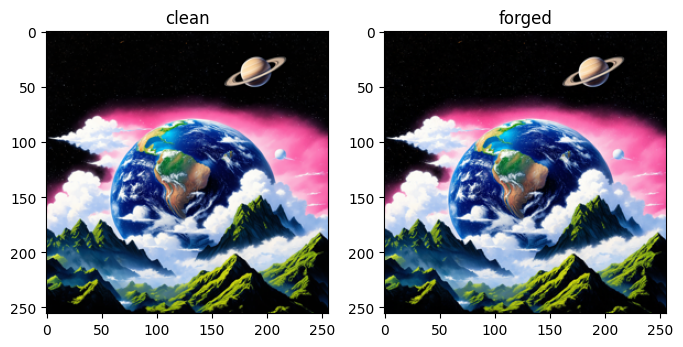

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].imshow(Image.open(DATASET_DIR / "clean_targets" / "1.png"))
axes[0].set_title("clean")
axes[1].imshow(Image.open(TEMP_OUT_DIR / "1.png"))
axes[1].set_title("forged")
plt.show()

In [ ]:
FILE_PATH = "submission.zip"
with zipfile.ZipFile(FILE_PATH, "w", zipfile.ZIP_DEFLATED) as zipf:
    for img_path in sorted(TEMP_OUT_DIR.glob("*.png")):
        zipf.write(img_path, arcname=img_path.name)
print("saved:", FILE_PATH)

saved: submission.zip


In [ ]:
correct_submission_path = "/content/submission.zip"

print(os.path.exists(correct_submission_path))
print(os.path.getsize(correct_submission_path), "bytes")

with zipfile.ZipFile(correct_submission_path) as z:
    names = z.namelist()
    print("num files:", len(names))
    print("first 5:", names[:5])

True
33487377 bytes
num files: 200
first 5: ['1.png', '10.png', '100.png', '101.png', '102.png']


In [ ]:
import requests

BASE_URL = "http://34.63.153.158"
API_KEY  = "613bfba4b9ba5a4c6bce1eeecb39f227"
TASK_ID  = "22-forging-task"
FILE_PATH = "/content/submission.zip" # Corrected path

with open(FILE_PATH, "rb") as f:
    files_payload = {"file": ("submission.zip", f, "zip")}
    resp = requests.post(
        f"{BASE_URL}/submit/{TASK_ID}",
        headers={"X-API-Key": API_KEY},
        files=files_payload,
    )

print("status code:", resp.status_code)
try:
    print("response json:", resp.json())
except Exception:
    print("response text:", resp.text)

status code: 200
response json: {'submission_id': 4723, 'status': 'success', 'message': 'Submission evaluated successfully! Check the leaderboard to see your score.'}
